# 03 - Bayesian Model Results

This notebook visualizes the posterior distributions from the hierarchical 
Bayesian model fitted in `models.py`. It provides the primary evidence for 
**Finding 1** and validates the modelling choices made during EDA.

## Structure

**Section 1 - Convergence verification**  
Trace plots for key parameters. All 4 NUTS chains mix cleanly (R-hat=1.000, 
Min ESS=1396). Included for reviewer transparency.

**Section 2 - Macro effects (Finding 1)**  
Posterior distributions of `beta_sp500` and `beta_vix`. Market uncertainty 
(VIX) shows a credible positive effect on forecast error (94% HDI excludes 
zero: [0.0013, 0.0102]). Market return direction does not (HDI includes zero).  
Interpretation: analysts underestimate more in high-uncertainty quarters, 
regardless of market direction.

**Section 3 - Category effects**  
Forest plot of `alpha_category` posteriors. Only `defensive_baseline` 
credibly separates from the grand mean (HDI=[-0.061, -0.010]), confirming 
its role as a structurally lower-bias control group. Other categories show 
consistent directional effects but wide credible intervals at the 
observation level — consistent with the bootstrap CI evidence from `02_eda`.

**Section 4 - Posterior predictive check**  
Observation-level posterior predictive samples overlaid on observed 
`forecast_error_winsorized`. The model captures central tendency and right 
skew. Remaining gap reflects unmodelled ticker-level heterogeneity.

**Section 5 - Likelihood justification**  
Posterior of `nu` (Student-t degrees of freedom): mean=1.146, 
94% HDI=[1.056, 1.232]. Far below the Normal approximation threshold (nu=30). 
Confirms the EDA QQ plot finding that a Normal likelihood would be 
misspecified for this data.

## Key outputs
- `reports/figures/03_trace_plots.png`
- `reports/figures/03_macro_posteriors.png`
- `reports/figures/03_category_forest_plot.png`
- `reports/figures/03_posterior_predictive_check.png`
- `reports/figures/03_nu_posterior.png`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import arviz as az
from pathlib import Path

ROOT      = Path("..")
MODELS    = ROOT / "models"
PROCESSED = ROOT / "data" / "processed"
FIGURES   = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

trace      = az.from_netcdf(str(MODELS / "trace.nc"))
summary_df = pd.read_csv(MODELS / "summary.csv")

print(trace)
print(f"\nSummary rows: {len(summary_df)}")

C:\Users\User\miniconda3\envs\forecast-bias\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

Summary rows: 11


In [2]:
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
})

CATEGORY_ORDER = [
    "commodity_driven",
    "macro_rate_sensitive",
    "tech_cycle",
    "economically_cyclical",
    "regulatory_idiosyncratic",
    "defensive_baseline",
]

CAT_COLORS = {
    "commodity_driven"         : "#e07b39",
    "macro_rate_sensitive"     : "#4c7fb5",
    "tech_cycle"               : "#7cb86e",
    "economically_cyclical"    : "#c45c8a",
    "regulatory_idiosyncratic" : "#9b6bb5",
    "defensive_baseline"       : "#999999",
}

## Section 1

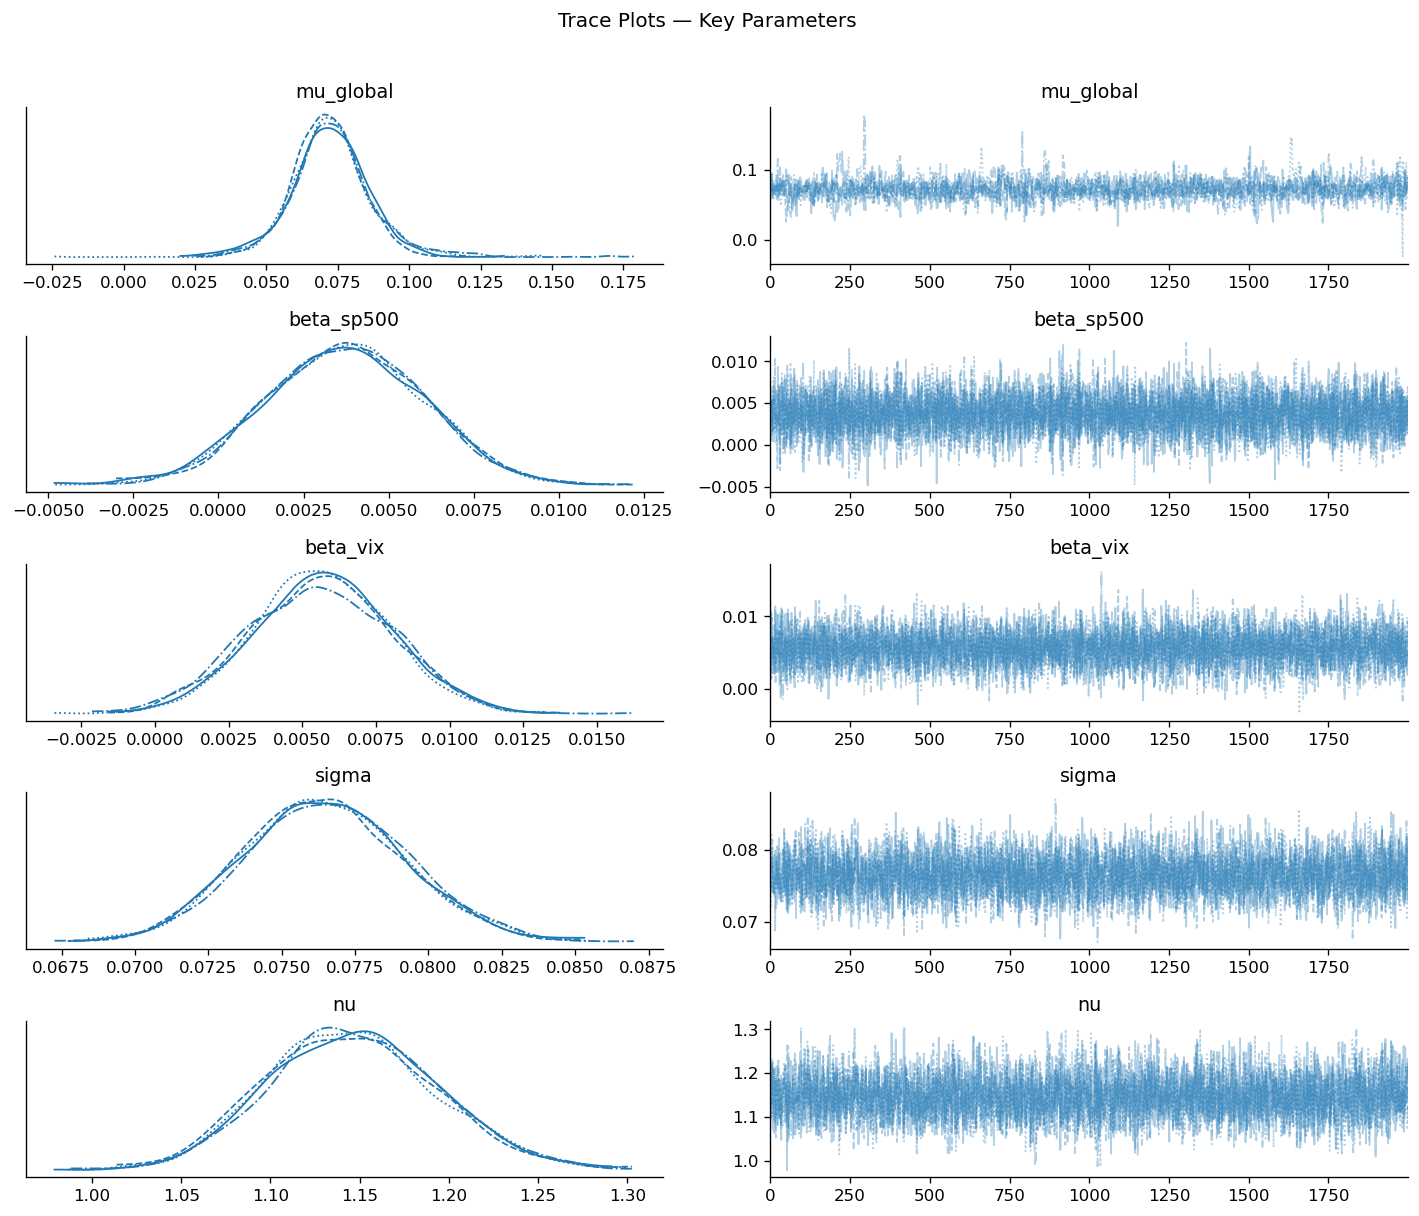

In [3]:
az.plot_trace(
    trace,
    var_names=["mu_global", "beta_sp500", "beta_vix", "sigma", "nu"],
    figsize=(12, 10),
    compact=True,
)
plt.suptitle("Trace Plots — Key Parameters", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "03_trace_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 2

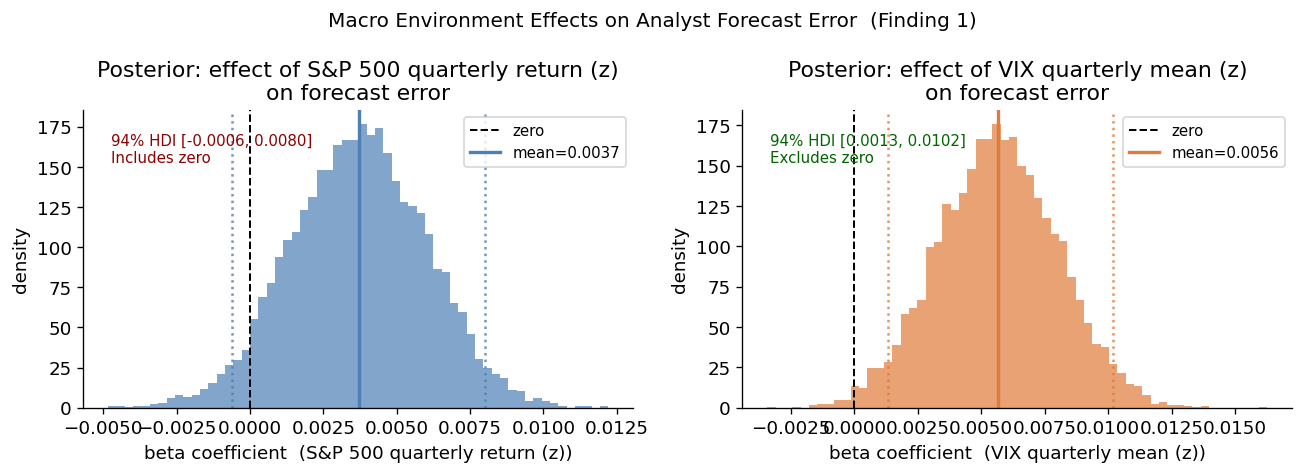

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, var, label, color in zip(
    axes,
    ["beta_sp500", "beta_vix"],
    ["S&P 500 quarterly return (z)", "VIX quarterly mean (z)"],
    ["#4c7fb5", "#e07b39"],
):
    samples = trace.posterior[var].values.flatten()
    
    ax.hist(samples, bins=60, color=color, alpha=0.7, density=True)
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--", label="zero")
    
    hdi = az.hdi(trace, var_names=[var], hdi_prob=0.94)[var].values
    ax.axvline(hdi[0], color=color, linewidth=1.5, linestyle=":", alpha=0.8)
    ax.axvline(hdi[1], color=color, linewidth=1.5, linestyle=":", alpha=0.8)
    ax.axvline(samples.mean(), color=color, linewidth=2, label=f"mean={samples.mean():.4f}")
    
    ax.set_xlabel(f"beta coefficient  ({label})")
    ax.set_ylabel("density")
    ax.set_title(f"Posterior: effect of {label}\non forecast error")
    ax.legend(fontsize=9)
    
    excludes_zero = hdi[0] > 0 or hdi[1] < 0
    ax.text(0.05, 0.92,
            f"94% HDI [{hdi[0]:.4f}, {hdi[1]:.4f}]\n"
            f"{'Excludes zero' if excludes_zero else 'Includes zero'}",
            transform=ax.transAxes, fontsize=9,
            color="darkgreen" if excludes_zero else "darkred",
            verticalalignment="top")

fig.suptitle("Macro Environment Effects on Analyst Forecast Error  (Finding 1)",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / "03_macro_posteriors.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 3

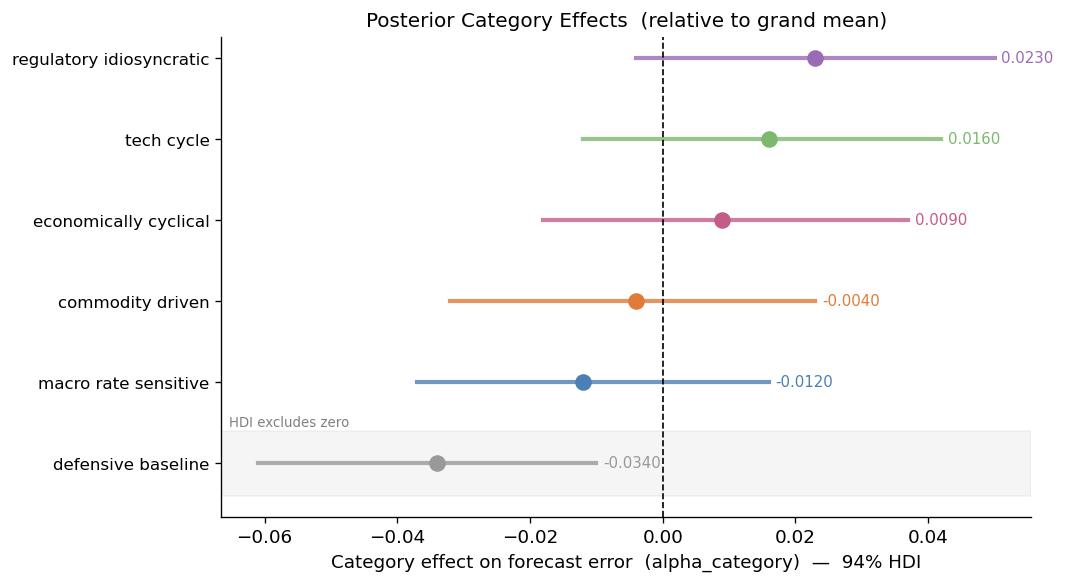

In [5]:
cat_rows = summary_df[summary_df["type"] == "category_effect"].copy()
cat_rows["category_short"] = cat_rows["category"].str.replace("_", " ")

cat_rows = cat_rows.sort_values("mean")

fig, ax = plt.subplots(figsize=(9, 5))

for i, (_, row) in enumerate(cat_rows.iterrows()):
    cat   = row["category"]
    color = CAT_COLORS[cat]
    ax.plot([row["hdi_3%"], row["hdi_97%"]], [i, i],
            color=color, linewidth=2.5, alpha=0.8)
    ax.scatter(row["mean"], i, color=color, s=80, zorder=5)
    ax.text(row["hdi_97%"] + 0.001, i, f"{row['mean']:.4f}",
            va="center", fontsize=9, color=color)

ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_yticks(range(len(cat_rows)))
ax.set_yticklabels(cat_rows["category_short"].tolist(), fontsize=10)
ax.set_xlabel("Category effect on forecast error  (alpha_category)  —  94% HDI")
ax.set_title("Posterior Category Effects  (relative to grand mean)", fontsize=12)

def_idx = cat_rows["category"].tolist().index("defensive_baseline")
ax.axhspan(def_idx - 0.4, def_idx + 0.4, color="grey", alpha=0.08)
ax.text(0.01, def_idx + 0.45, "HDI excludes zero",
        fontsize=8, color="grey", transform=ax.get_yaxis_transform())

plt.tight_layout()
plt.savefig(FIGURES / "03_category_forest_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4

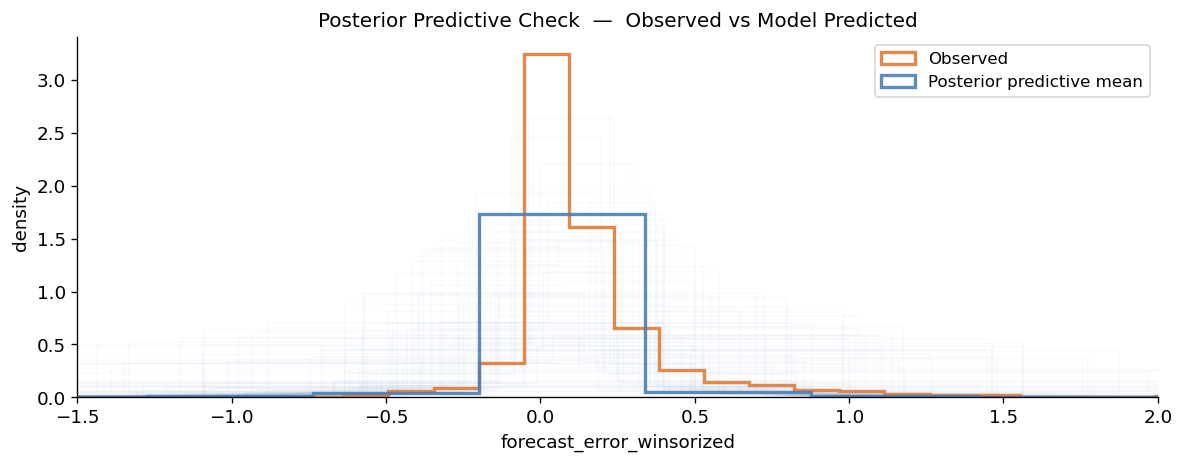

In [7]:
panel    = pd.read_parquet(PROCESSED / "panel.parquet")
features = pd.read_parquet(PROCESSED / "features.parquet")

df = panel[panel["year"] < 2026].merge(
    features, on=["act_symbol", "period_end_date"], how="left"
).dropna(subset=["forecast_error_winsorized", "sp500_return_z"])

y_obs    = df["forecast_error_winsorized"].values
cat_idx  = pd.Categorical(df["category"], categories=CATEGORY_ORDER).codes
sp500_z  = df["sp500_return_z"].values
vix_z    = df["vix_mean_z"].values

rng       = np.random.default_rng(42)
n_samples = 200

mu_global_s      = trace.posterior["mu_global"].values.flatten()
alpha_category_s = trace.posterior["alpha_category"].values.reshape(-1, 6)
beta_sp500_s     = trace.posterior["beta_sp500"].values.flatten()
beta_vix_s       = trace.posterior["beta_vix"].values.flatten()
sigma_s          = trace.posterior["sigma"].values.flatten()
nu_s             = trace.posterior["nu"].values.flatten()

idx = rng.integers(0, len(mu_global_s), size=n_samples)

from scipy.stats import t as student_t

ppc_samples = []
for i in idx:
    mu = (
        mu_global_s[i]
        + alpha_category_s[i][cat_idx]
        + beta_sp500_s[i] * sp500_z
        + beta_vix_s[i]   * vix_z
    )
    draws = student_t.rvs(df=nu_s[i], loc=mu, scale=sigma_s[i],
                          random_state=rng)
    ppc_samples.append(draws)

ppc_samples = np.array(ppc_samples)

fig, ax = plt.subplots(figsize=(10, 4))

for i in range(min(80, n_samples)):
    ax.hist(ppc_samples[i], bins=60, density=True, alpha=0.03,
            color="#4c7fb5", histtype="step")

ax.hist(y_obs, bins=60, density=True, alpha=0.9,
        color="#e07b39", label="Observed", histtype="step", linewidth=2)
ax.hist(ppc_samples.mean(axis=0), bins=60, density=True, alpha=0.9,
        color="#4c7fb5", label="Posterior predictive mean",
        histtype="step", linewidth=2)

ax.set_xlim(-1.5, 2.0)
ax.set_xlabel("forecast_error_winsorized")
ax.set_ylabel("density")
ax.set_title("Posterior Predictive Check  —  Observed vs Model Predicted", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES / "03_posterior_predictive_check.png", dpi=150, bbox_inches="tight")
plt.show()

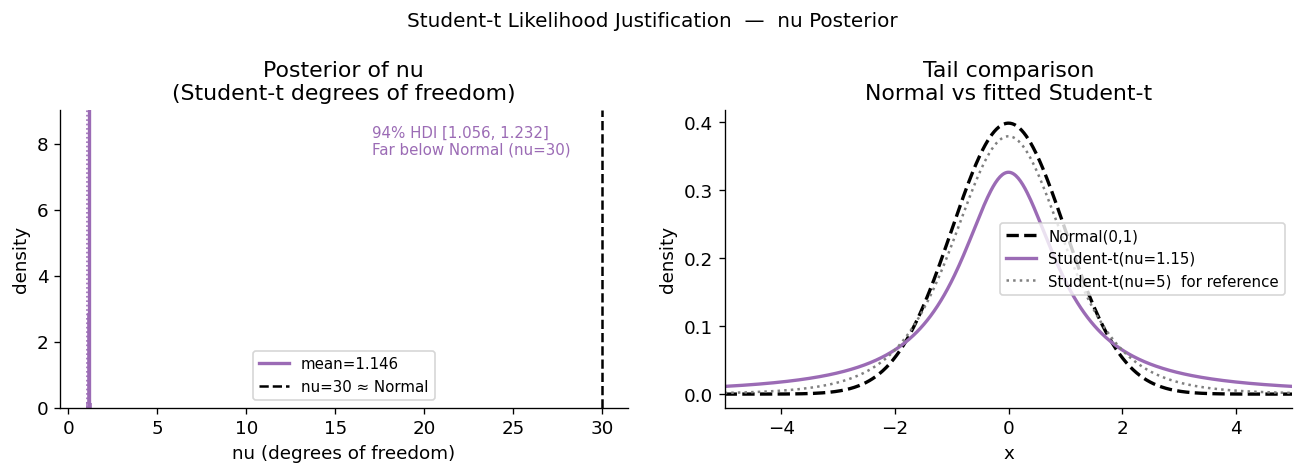

In [8]:
from scipy.stats import t as student_t, norm

nu_samples = trace.posterior["nu"].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(nu_samples, bins=60, color="#9b6bb5", alpha=0.8, density=True)
axes[0].axvline(nu_samples.mean(), color="#9b6bb5", linewidth=2,
                label=f"mean={nu_samples.mean():.3f}")
axes[0].axvline(30, color="black", linewidth=1.5, linestyle="--",
                label="nu=30 ≈ Normal")
hdi_nu = az.hdi(trace, var_names=["nu"], hdi_prob=0.94)["nu"].values
axes[0].axvline(hdi_nu[0], color="#9b6bb5", linewidth=1, linestyle=":")
axes[0].axvline(hdi_nu[1], color="#9b6bb5", linewidth=1, linestyle=":")
axes[0].set_xlabel("nu (degrees of freedom)")
axes[0].set_ylabel("density")
axes[0].set_title("Posterior of nu\n(Student-t degrees of freedom)")
axes[0].legend(fontsize=9)
axes[0].text(0.55, 0.85,
             f"94% HDI [{hdi_nu[0]:.3f}, {hdi_nu[1]:.3f}]\nFar below Normal (nu=30)",
             transform=axes[0].transAxes, fontsize=9, color="#9b6bb5")

x = np.linspace(-5, 5, 500)
axes[1].plot(x, norm.pdf(x), color="black", linewidth=2,
             linestyle="--", label="Normal(0,1)")
axes[1].plot(x, student_t.pdf(x, df=1.15), color="#9b6bb5", linewidth=2,
             label=f"Student-t(nu={nu_samples.mean():.2f})")
axes[1].plot(x, student_t.pdf(x, df=5), color="grey", linewidth=1.5,
             linestyle=":", label="Student-t(nu=5)  for reference")
axes[1].set_xlim(-5, 5)
axes[1].set_xlabel("x")
axes[1].set_ylabel("density")
axes[1].set_title("Tail comparison\nNormal vs fitted Student-t")
axes[1].legend(fontsize=9)

fig.suptitle("Student-t Likelihood Justification  —  nu Posterior", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / "03_nu_posterior.png", dpi=150, bbox_inches="tight")
plt.show()